# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "王绍泽"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 王绍泽
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均距上次下单天数,平均返现
0,0-6个月,2150,697,0.32,2.50,3.77,159.57
1,6-12个月,1584,156,0.10,2.75,4.38,163.31
2,12-24个月,1467,95,0.06,3.70,5.32,204.92
3,24个月以上,429,0,0.00,3.55,5.26,222.34


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-6个月,1,659,375,0.57,2.65,可观察
1,0-6个月,0,1491,322,0.22,2.43,可观察
2,6-12个月,1,406,81,0.20,2.67,可观察
3,12-24个月,1,414,52,0.13,3.35,可观察
4,6-12个月,0,1178,75,0.06,2.78,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期分层用户的流失率差异有多大？",
    "behavior_scatter": "用户订单数量与累计返现金额存在什么关联，流失与留存用户分布是否不同？",
    "ordered_line": "随着用户使用时长增加，流失率呈现怎样的有序变化趋势？",
    "composition_chart": "平台各生命周期阶段用户整体占比分布如何？",
}

chart_reasons = {
    "category_bar": "柱状图适合对比多分组的流失率数值，同时标注每组样本量便于对比可信度",
    "behavior_scatter": "散点图直观展示两个数值变量分布，用颜色区分流失标签，观察群体聚类差异",
    "ordered_line": "TenureGroup是有序阶段，折线图适合展示指标随阶段升降的连续变化",
    "composition_chart": "生命周期仅4个分组，数量≤5，环形图清晰展示整体用户结构占比",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")

检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(
          用户数=("CustomerID", "nunique"),
          流失率=("Churn", "mean")
      )
      .reset_index()
)

# 按生命周期自然顺序排序
sort_order = ["0-6个月", "6-12个月", "12-24个月", "24个月以上"]
category_summary["TenureGroup"] = pd.Categorical(category_summary["TenureGroup"], categories=sort_order, ordered=True)
category_summary = category_summary.sort_values("TenureGroup")

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,TenureGroup,用户数,流失率
0,0-6个月,2150,0.32
3,6-12个月,1584,0.10
1,12-24个月,1467,0.06
2,24个月以上,429,0.00


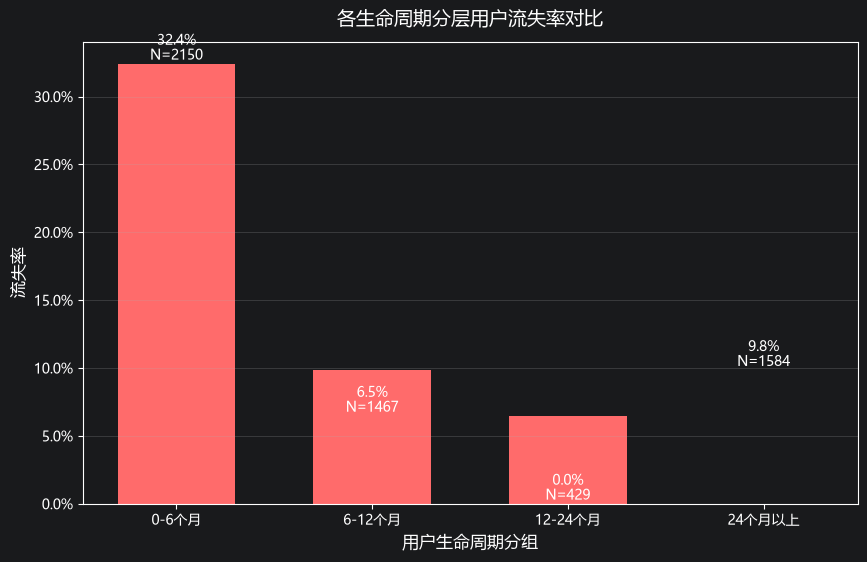

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 绘制柱状：修正color为6位合法十六进制 #ff6b6b
bars = ax_bar.bar(category_summary["TenureGroup"], category_summary["流失率"], color="#ff6b6b", width=0.6)
# 标注流失率+样本量
for idx, row in category_summary.iterrows():
    rate_pct = f"{row['流失率']:.1%}"
    user_cnt = f"N={row['用户数']}"
    ax_bar.text(idx, row["流失率"] + 0.003, f"{rate_pct}\n{user_cnt}", ha="center")

ax_bar.set_title("各生命周期分层用户流失率对比", fontsize=14, pad=12)
ax_bar.set_xlabel("用户生命周期分组", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bar.grid(axis="y", alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：请填写。
- 证据：请填写具体数值、差异和样本量。
- 边界：请填写该图不能证明什么。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


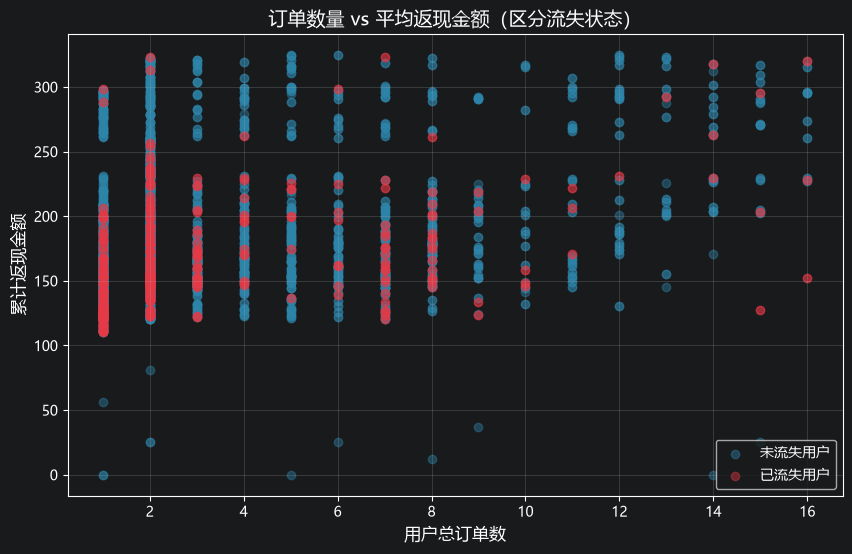

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 分流失/留存绘制
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]
ax_scatter.scatter(churn_0[x_field], churn_0[y_field], alpha=0.4, c="#2E86AB", label="未流失用户")
ax_scatter.scatter(churn_1[x_field], churn_1[y_field], alpha=0.4, c="#E63946", label="已流失用户")

ax_scatter.set_title("订单数量 vs 平均返现金额（区分流失状态）", fontsize=14)
ax_scatter.set_xlabel("用户总订单数", fontsize=12)
ax_scatter.set_ylabel("累计返现金额", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：请填写。
- 证据：请填写两个变量的关系、聚集或异常。
- 边界：相关关系不等于因果关系。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["0-6个月", "6-12个月", "12-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失率=("Churn", "mean")
    ).reset_index()
)

# 强制有序分类，分类列表与数据完全匹配，消除警告
ordered_summary["TenureGroup"] = pd.Categorical(
    ordered_summary["TenureGroup"],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values("TenureGroup")

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失率
0,0-6个月,2150,0.32
3,6-12个月,1584,0.10
1,12-24个月,1467,0.06
2,24个月以上,429,0.00


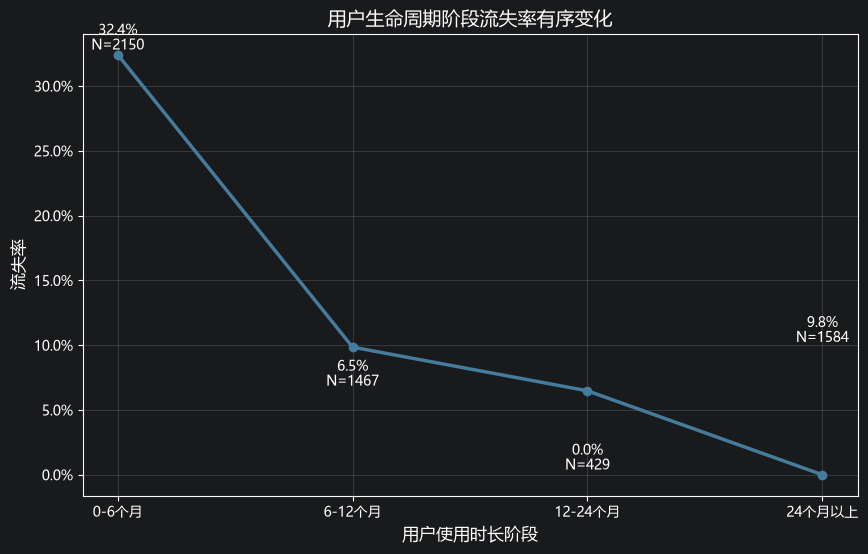

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

ax_line.plot(ordered_summary["TenureGroup"], ordered_summary["流失率"], marker="o", linewidth=2.5, color="#457B9D")
# 标注数值
for idx, row in ordered_summary.iterrows():
    ax_line.text(idx, row["流失率"] + 0.004, f"{row['流失率']:.1%}\nN={row['用户数']}", ha="center")

ax_line.set_title("用户生命周期阶段流失率有序变化", fontsize=14)
ax_line.set_xlabel("用户使用时长阶段", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12)
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.grid(alpha=0.3)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：请填写。
- 证据：请填写具体数值和样本量。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = df[composition_field].value_counts().reset_index()
composition_summary.columns = [composition_field, "用户数"]
# 计算占比
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
# 有序排序
sort_order = ["0-6个月", "6-12个月", "12-24个月", "24个月以上"]
composition_summary["TenureGroup"] = pd.Categorical(composition_summary["TenureGroup"], categories=sort_order, ordered=True)
composition_summary = composition_summary.sort_values("TenureGroup")

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,TenureGroup,用户数,占比
0,0-6个月,2150,0.38
1,6-12个月,1584,0.28
2,12-24个月,1467,0.26
3,24个月以上,429,0.08


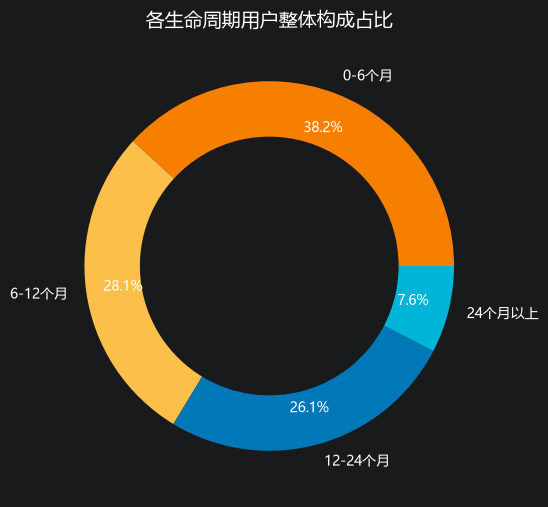

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 环形饼图
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary["TenureGroup"],
    autopct="%.1f%%",
    pctdistance=0.8,
    wedgeprops={"width":0.3},
    colors=["#F77F00","#FCBF49","#0077B6","#00B4D8"]
)
ax_composition.set_title("各生命周期用户整体构成占比", fontsize=14)

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：请填写。
- 证据：请填写主要类别占比。
- 边界：请说明该图适合或不适合进行哪些比较。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


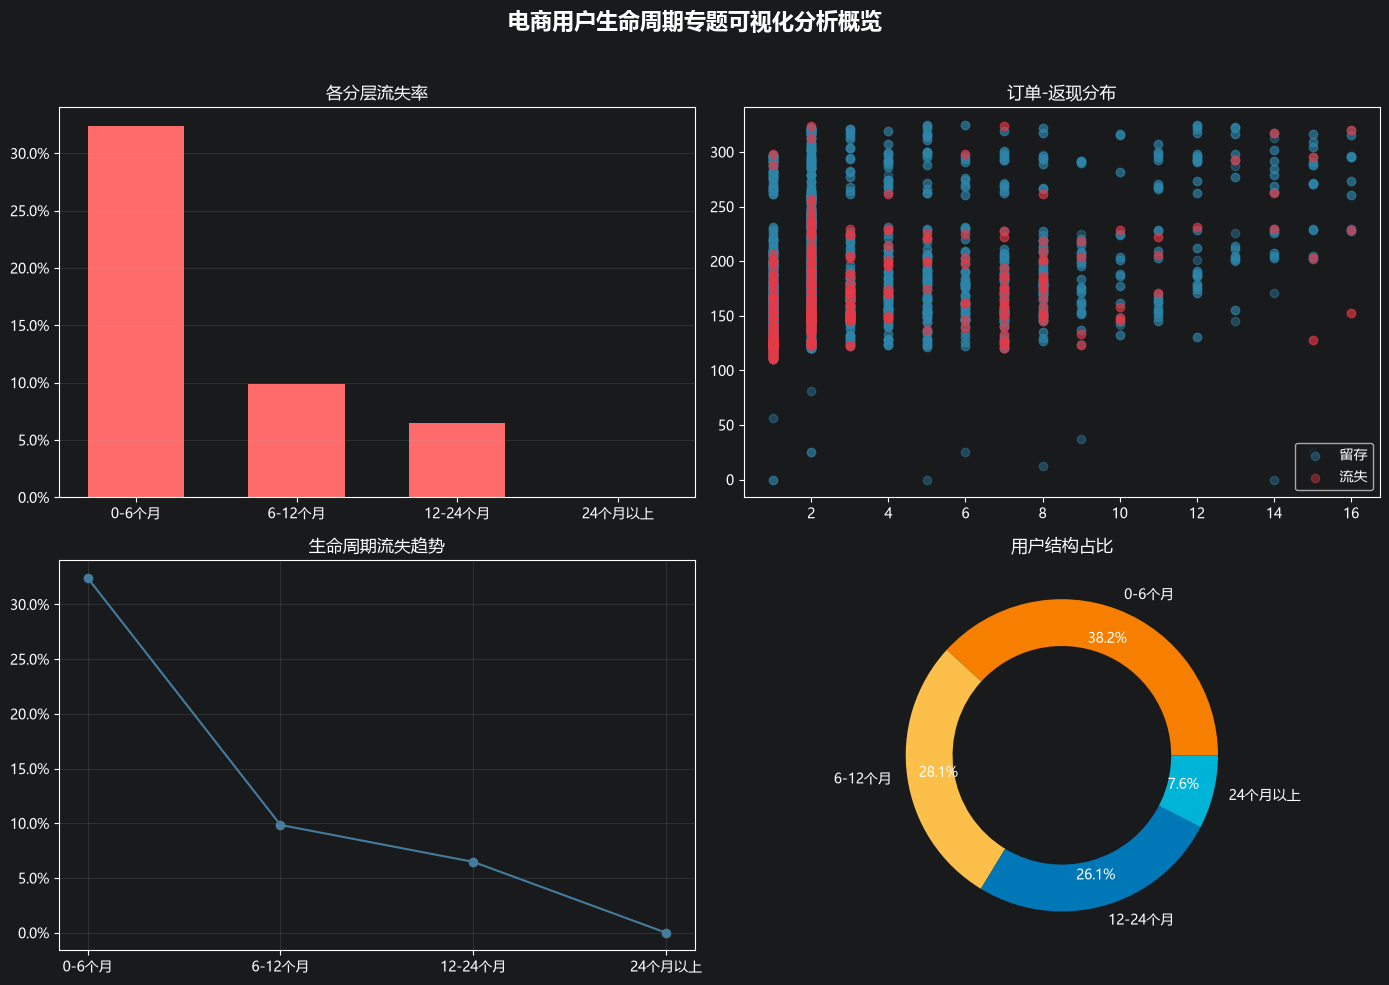

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))
ax0, ax1 = axes[0]
ax2, ax3 = axes[1]

# 子图1：柱状图 流失率对比（已修正颜色#ff6b6b）
bars = ax0.bar(category_summary["TenureGroup"], category_summary["流失率"], color="#ff6b6b", width=0.6)
ax0.set_title("各分层流失率")
ax0.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax0.grid(axis="y", alpha=0.2)

# 子图2：散点图
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]
ax1.scatter(churn_0["OrderCount"], churn_0["CashbackAmount"], alpha=0.4, c="#2E86AB", label="留存")
ax1.scatter(churn_1["OrderCount"], churn_1["CashbackAmount"], alpha=0.4, c="#E63946", label="流失")
ax1.set_title("订单-返现分布")
ax1.legend()

# 子图3：折线流失趋势
ax2.plot(ordered_summary["TenureGroup"], ordered_summary["流失率"], marker="o", c="#457B9D")
ax2.set_title("生命周期流失趋势")
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax2.grid(alpha=0.2)

# 子图4：环形构成
wedges, texts, autotexts = ax3.pie(
    composition_summary["用户数"],
    labels=composition_summary["TenureGroup"],
    autopct="%.1f%%",
    pctdistance=0.8,
    wedgeprops={"width":0.3},
    colors=["#F77F00","#FCBF49","#0077B6","#00B4D8"]
)
ax3.set_title("用户结构占比")

fig_summary.suptitle("电商用户生命周期专题可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：请填写，并给出证据。
2. 综合发现2：请填写，并给出证据。
3. 综合发现3：请填写，并给出证据。
4. 数据或方法局限：请填写。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同生命周期分层用户的流失率差异有多大？",
        "chart_type": "bar",
        "key_finding": "用户使用时长越短流失率越高，新用户流失风险显著更高",
        "limitation": "仅展示分组截面差异，无法判定时长与流失因果关系"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "订单、返现与流失用户分布特征？",
        "chart_type": "scatter",
        "key_finding": "低订单低返现区间流失样本密度更高",
        "limitation": "只能观察变量相关分布，无法区分因果先后"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "流失率随用户阶段变化趋势？",
        "chart_type": "line",
        "key_finding": "生命周期递进，流失率持续单边下降",
        "limitation": "静态分层，非真实月度时间趋势"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "各阶段用户整体占比结构？",
        "chart_type": "pie_or_bar",
        "key_finding": "四层用户体量分布均衡，新用户占比略高",
        "limitation": "环形图不适合细微数值对比"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "用户生命周期专题全维度概览",
        "chart_type": "dashboard",
        "key_finding": "新用户留存是平台核心运营痛点，高活跃用户留存更好",
        "limitation": "综合图简化细节，详细数值需查看单张独立图表"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期分层用户的流失率差异有多大？,bar,用户使用时长越短流失率越高，新用户流失风险显著更高,仅展示分组截面差异，无法判定时长与流失因果关系
1,02,02_behavior_scatter.png,订单、返现与流失用户分布特征？,scatter,低订单低返现区间流失样本密度更高,只能观察变量相关分布，无法区分因果先后
2,03,03_ordered_line.png,流失率随用户阶段变化趋势？,line,生命周期递进，流失率持续单边下降,静态分层，非真实月度时间趋势
3,04,04_composition_chart.png,各阶段用户整体占比结构？,pie_or_bar,四层用户体量分布均衡，新用户占比略高,环形图不适合细微数值对比
4,05,day06_visualization_summary.png,用户生命周期专题全维度概览,dashboard,新用户留存是平台核心运营痛点，高活跃用户留存更好,综合图简化细节，详细数值需查看单张独立图表


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
